In [1]:
import os
import pickle
import sys

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
import pandas as pd
from tqdm import tqdm

sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, MODEL_MARKERS, FONT_SIZES

plt.rcParams.update(FONT_SIZES)

In [2]:
project_root = "../../../.."

all_test_accessions = open(f"{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt").read().splitlines()

# Toggle: set True to load pre-computed results from disk (fast), False to run full data processing
LOAD_PROCESSED_DATA = True

# Load genome info for TT classification
genome_info_df = pd.read_csv(f"{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv")
genome_info_df = genome_info_df.set_index('accession')

TT4_FAMILIES = ['Mycoplasmataceae']

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        translation_table = 4 if row['family'] in TT4_FAMILIES else 11
        all_genomes[acc] = {
            'family': row['family'],
            'gc_content': row['gc_content'],
            'translation_table': translation_table
        }

print(f"Total test accessions: {len(all_test_accessions)}")

read_lengths = [75, 100, 150, 300, 700, 1000]

models_per_length = {
    75:   ["fgs_complete", "prodigal", "deep_cds"],
    100:  ["fgs_complete", "prodigal", "deep_cds"],
    150:  ["fgs_complete", "prodigal", "deep_cds"],
    300:  ["fgs_complete", "prodigal", "deep_cds"],
    700:  ["fgs_complete", "prodigal", "deep_cds"],
    1000: ["fgs_complete", "prodigal", "deep_cds"],
}

model_names = ["fgs_complete", "prodigal", "deep_cds"]

model_display_names = MODEL_DISPLAY_NAMES
model_colors = MODEL_COLORS
model_markers = MODEL_MARKERS

_script_name = "start_stop_codon_evaluation"
_cache_dir = f"{project_root}/data/processed_data/report_results/without_errors/{_script_name}"

Total test accessions: 215


In [3]:
def load_testset(test_accession, data_type, project_root=project_root):
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/testset_dict.pkl", "rb") as f:
        testset_dict = pickle.load(f)
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as f:
        read_names_list = pickle.load(f)
    return read_names_list, testset_dict


def load_model_preds(test_accession, data_type, model_name, project_root=project_root):
    pred_paths = {
        "prodigal": f"{project_root}/data/processed_data/predictions/processed_predictions/prodigal_preds/{data_type}/{test_accession}/model_preds_dict.pkl",
        "fgs_complete": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}/{test_accession}.pkl",
        "deep_cds": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_without_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl",
    }
    with open(pred_paths[model_name], "rb") as f:
        preds = pickle.load(f)
    return preds

In [4]:
def is_internal_start(start, rf):
    """Return True if a CDS start is truncated at the read boundary.
    A start is internal when it sits at position rf+1 (the very first in-frame
    codon position), meaning no complete start codon can be observed.
    For disrupted_rf entries the original rf is unknown, so any of the three
    possible boundary positions (1, 2, 3) is treated as internal."""
    if rf == 'disrupted_rf':
        return start in {1, 2, 3}
    rf_int = int(rf)
    return start == rf_int + 1


def is_internal_stop(stop, seq_len, rf):
    """Return True if a CDS stop is truncated at the read boundary.
    A stop is internal when it falls within 2 bp of the end of the read."""
    return stop >= seq_len - 2


def get_codon_sets(cds_coords, seq_len):
    """Extract sets of real (non-internal) start and stop codon positions.
    Returns sets of (position, rf) tuples."""
    real_starts = set()
    real_stops = set()
    for start, stop, rf in cds_coords:
        if not is_internal_start(start, rf):
            real_starts.add((start, rf))
        if not is_internal_stop(stop, seq_len, rf):
            real_stops.add((stop, rf))
    return real_starts, real_stops


def compute_codon_detection_counts(pred_coords, actual_coords, seq_len):
    """Compute TP/FP/FN for start and stop codon detection (exact position match)."""
    pred_starts, pred_stops = get_codon_sets(pred_coords, seq_len)
    actual_starts, actual_stops = get_codon_sets(actual_coords, seq_len)
    
    start_tp = len(pred_starts & actual_starts)
    start_fp = len(pred_starts - actual_starts)
    start_fn = len(actual_starts - pred_starts)
    
    stop_tp = len(pred_stops & actual_stops)
    stop_fp = len(pred_stops - actual_stops)
    stop_fn = len(actual_stops - pred_stops)
    
    return start_tp, start_fp, start_fn, stop_tp, stop_fp, stop_fn

# Evaluate start/stop codon prediction across read lengths

In [5]:
import os

if not LOAD_PROCESSED_DATA:
    def _init_codon_dict():
        return {
            length: {model: {
                'start_tp': 0, 'start_fp': 0, 'start_fn': 0,
                'stop_tp': 0, 'stop_fp': 0, 'stop_fn': 0,
            } for model in model_names}
            for length in read_lengths
        }

    def _init_has_data_dict():
        return {length: {model: False for model in model_names} for length in read_lengths}

    results = _init_codon_dict()
    has_data = _init_has_data_dict()

    # Per-genome metric lists for boxplots (excludes TT4, mirrors results aggregation)
    per_genome_metrics_list = {
        length: {model: {
            'start_f1': [], 'start_precision': [], 'start_recall': [],
            'stop_f1': [],  'stop_precision': [],  'stop_recall': [],
        } for model in model_names}
        for length in read_lengths
    }

    for length in read_lengths:
        data_type = f"without_errors_{length}bp"
        seq_len = length
        available_models = models_per_length[length]
        print(f"\nProcessing {data_type} (models: {', '.join(available_models)})...")
    
        for test_accession in tqdm(all_test_accessions, desc=f"{length}bp"):
            # Exclude TT4 genomes for fair comparison
            tt = all_genomes.get(test_accession, {}).get('translation_table', None)
            if tt == 4:
                continue
        
            try:
                read_names_list, testset_dict = load_testset(test_accession, data_type)
            except Exception as e:
                print(f"Error loading testset for {test_accession} at {length}bp: {e}")
                continue
        
            for model in available_models:
                try:
                    preds = load_model_preds(test_accession, data_type, model)
                except Exception as e:
                    print(f"Error loading {model} for {test_accession} at {length}bp: {e}")
                    continue
            
                has_data[length][model] = True
            
                # Per-genome accumulators (reset for each accession)
                pg_s_tp = pg_s_fp = pg_s_fn = 0
                pg_e_tp = pg_e_fp = pg_e_fn = 0
            
                for read_name in read_names_list:
                    actual = testset_dict.get(read_name, {}).get('cds_coords', [])
                    predicted = preds.get(read_name, {}).get('cds_coords', [])
                
                    s_tp, s_fp, s_fn, e_tp, e_fp, e_fn = compute_codon_detection_counts(
                        predicted, actual, seq_len)
                    results[length][model]['start_tp'] += s_tp
                    results[length][model]['start_fp'] += s_fp
                    results[length][model]['start_fn'] += s_fn
                    results[length][model]['stop_tp'] += e_tp
                    results[length][model]['stop_fp'] += e_fp
                    results[length][model]['stop_fn'] += e_fn
                    pg_s_tp += s_tp; pg_s_fp += s_fp; pg_s_fn += s_fn
                    pg_e_tp += e_tp; pg_e_fp += e_fp; pg_e_fn += e_fn
            
                # Compute per-genome detection metrics and store for boxplots
                s_prec = pg_s_tp / (pg_s_tp + pg_s_fp) if (pg_s_tp + pg_s_fp) > 0 else 0.0
                s_rec  = pg_s_tp / (pg_s_tp + pg_s_fn) if (pg_s_tp + pg_s_fn) > 0 else 0.0
                s_f1   = 2 * s_prec * s_rec / (s_prec + s_rec) if (s_prec + s_rec) > 0 else 0.0
                e_prec = pg_e_tp / (pg_e_tp + pg_e_fp) if (pg_e_tp + pg_e_fp) > 0 else 0.0
                e_rec  = pg_e_tp / (pg_e_tp + pg_e_fn) if (pg_e_tp + pg_e_fn) > 0 else 0.0
                e_f1   = 2 * e_prec * e_rec / (e_prec + e_rec) if (e_prec + e_rec) > 0 else 0.0
                per_genome_metrics_list[length][model]['start_f1'].append(s_f1)
                per_genome_metrics_list[length][model]['start_precision'].append(s_prec)
                per_genome_metrics_list[length][model]['start_recall'].append(s_rec)
                per_genome_metrics_list[length][model]['stop_f1'].append(e_f1)
                per_genome_metrics_list[length][model]['stop_precision'].append(e_prec)
                per_genome_metrics_list[length][model]['stop_recall'].append(e_rec)

else:

    print(f"Loading pre-computed results from:\n  {_cache_dir}")
    with open(os.path.join(_cache_dir, "results.pkl"), "rb") as f:
        results = pickle.load(f)
    with open(os.path.join(_cache_dir, "has_data.pkl"), "rb") as f:
        has_data = pickle.load(f)
    with open(os.path.join(_cache_dir, "per_genome_metrics_list.pkl"), "rb") as f:
        per_genome_metrics_list = pickle.load(f)

Loading pre-computed results from:
  ../../../../data/processed_data/report_results/without_errors/start_stop_codon_evaluation


In [6]:
if not LOAD_PROCESSED_DATA:
    os.makedirs(_cache_dir, exist_ok=True)
    _objects_to_save = {
        "results": results,
        "has_data": has_data,
        "per_genome_metrics_list": per_genome_metrics_list,
    }
    for _name, _obj in _objects_to_save.items():
        with open(os.path.join(_cache_dir, f"{_name}.pkl"), "wb") as f:
            pickle.dump(_obj, f)
    print(f"Results saved to {_cache_dir}")

In [7]:
def safe_div(a, b):
    return a / b if b > 0 else 0.0

metrics = {model: {
    'start_precision': [], 'start_recall': [], 'start_f1': [],
    'stop_precision': [], 'stop_recall': [], 'stop_f1': [],
} for model in model_names}

for length in read_lengths:
    for model in model_names:
        if not has_data[length][model]:
            for key in metrics[model]:
                metrics[model][key].append(np.nan)
            continue
        
        r = results[length][model]
        
        s_prec = safe_div(r['start_tp'], r['start_tp'] + r['start_fp'])
        s_rec = safe_div(r['start_tp'], r['start_tp'] + r['start_fn'])
        s_f1 = safe_div(2 * s_prec * s_rec, s_prec + s_rec)
        
        e_prec = safe_div(r['stop_tp'], r['stop_tp'] + r['stop_fp'])
        e_rec = safe_div(r['stop_tp'], r['stop_tp'] + r['stop_fn'])
        e_f1 = safe_div(2 * e_prec * e_rec, e_prec + e_rec)
        
        metrics[model]['start_precision'].append(s_prec)
        metrics[model]['start_recall'].append(s_rec)
        metrics[model]['start_f1'].append(s_f1)
        metrics[model]['stop_precision'].append(e_prec)
        metrics[model]['stop_recall'].append(e_rec)
        metrics[model]['stop_f1'].append(e_f1)

# Plots: Start and stop codon prediction by read length

In [13]:
def plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, metric_key, ylabel, title):
    """Plot per-genome metric distributions as grouped boxplots across read lengths.

    Args:
        per_genome_metrics_list: Dict of {length: {model: {metric_key: [values_per_genome]}}}.
        read_lengths: List of read lengths for the x-axis.
        metric_key: Key into per_genome_metrics_list (e.g. 'start_f1', 'stop_recall').
        ylabel: Y-axis label.
        title: Plot title.
    """
    active_models = [m for m in model_names
                     if any(per_genome_metrics_list[l][m][metric_key] for l in read_lengths)]
    if not active_models:
        print("No data available.")
        return

    n_active = len(active_models)
    matplotlib.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(figsize=(11, 7))

    x_positions = np.arange(len(read_lengths))
    box_width = 0.8 / n_active
    offsets = (np.arange(n_active) - (n_active - 1) / 2) * box_width

    for k, model in enumerate(active_models):
        color = model_colors[model]
        positions, data = [], []
        for i, length in enumerate(read_lengths):
            vals = per_genome_metrics_list[length][model][metric_key]
            if vals:
                positions.append(x_positions[i] + offsets[k])
                data.append(vals)
        if not data:
            continue

        bp = ax.boxplot(
            data,
            patch_artist=True,
            positions=positions,
            widths=box_width * 0.9,
            showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.5,
                            markerfacecolor=color, markeredgecolor=color),
            manage_ticks=False,
        )
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for line in bp['medians']:
            line.set_color('black')
            line.set_linewidth(1.5)
        ax.plot([], [], color=color, linewidth=6, alpha=0.7,
                label=model_display_names[model])

    ax.set_xlabel('Read Length (bp)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=14)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(l) for l in read_lengths])
    ax.set_ylim(0, 1.01)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=4)

    plt.tight_layout()
    # plt.savefig(f"{metric_key}_by_read_length_boxplot.svg", dpi=500)
    plt.show()

## Start codon prediction

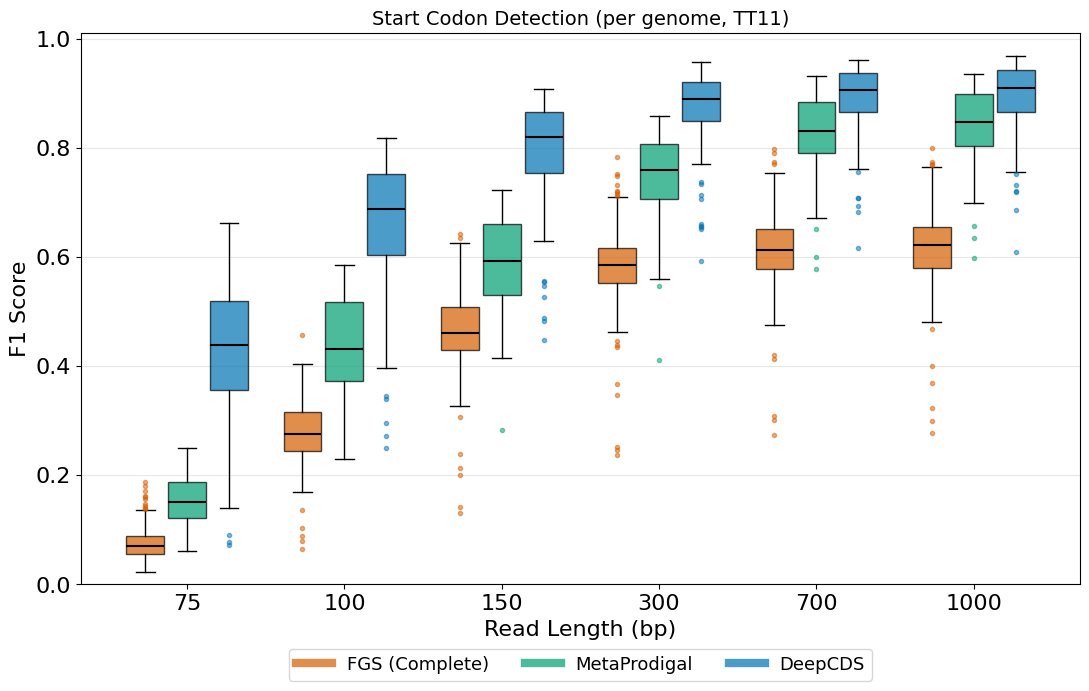

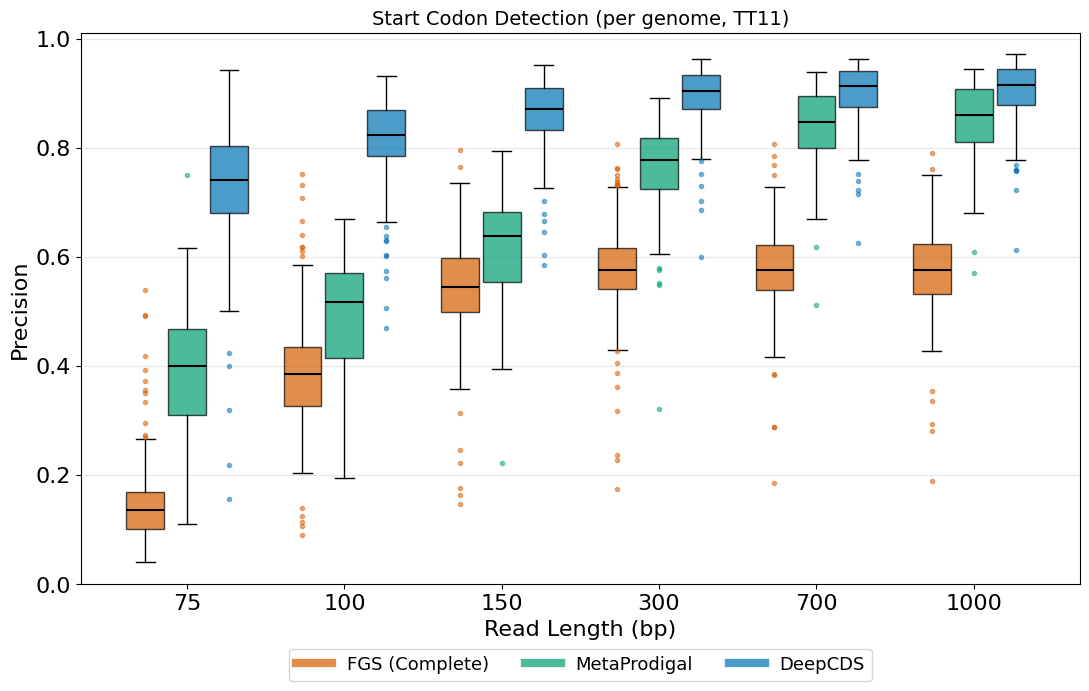

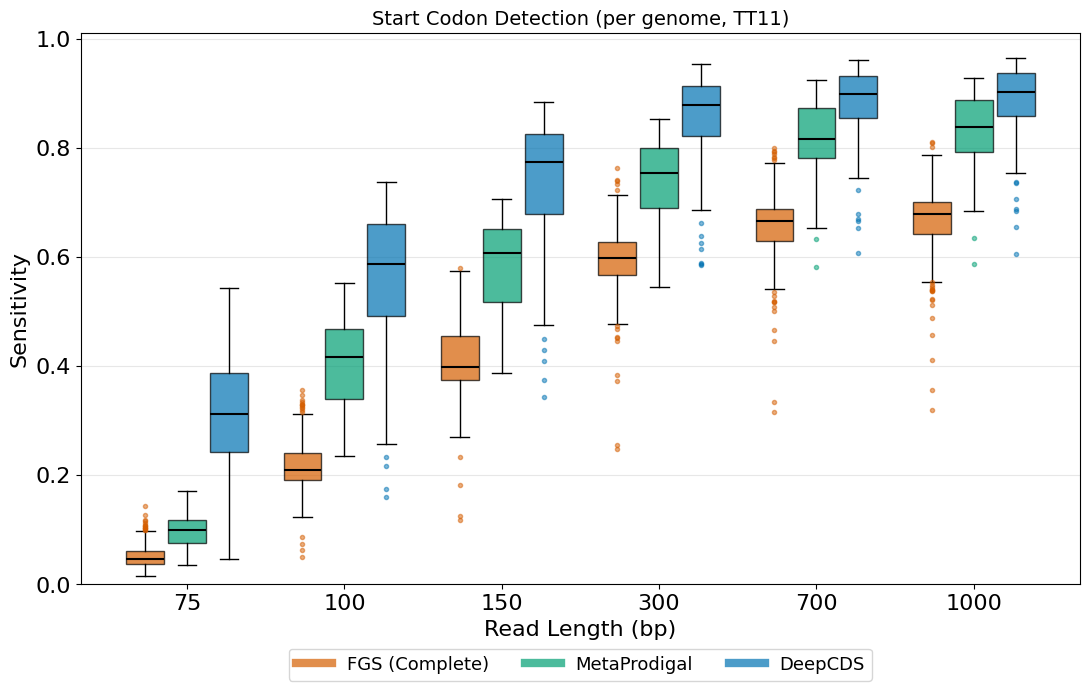

In [18]:
plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, 'start_f1', 'F1 Score',
                          'Start Codon Detection (per genome, TT11)')
plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, 'start_precision', 'Precision',
                          'Start Codon Detection (per genome, TT11)')
plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, 'start_recall', 'Sensitivity',
                          'Start Codon Detection (per genome, TT11)')

## Stop codon prediction

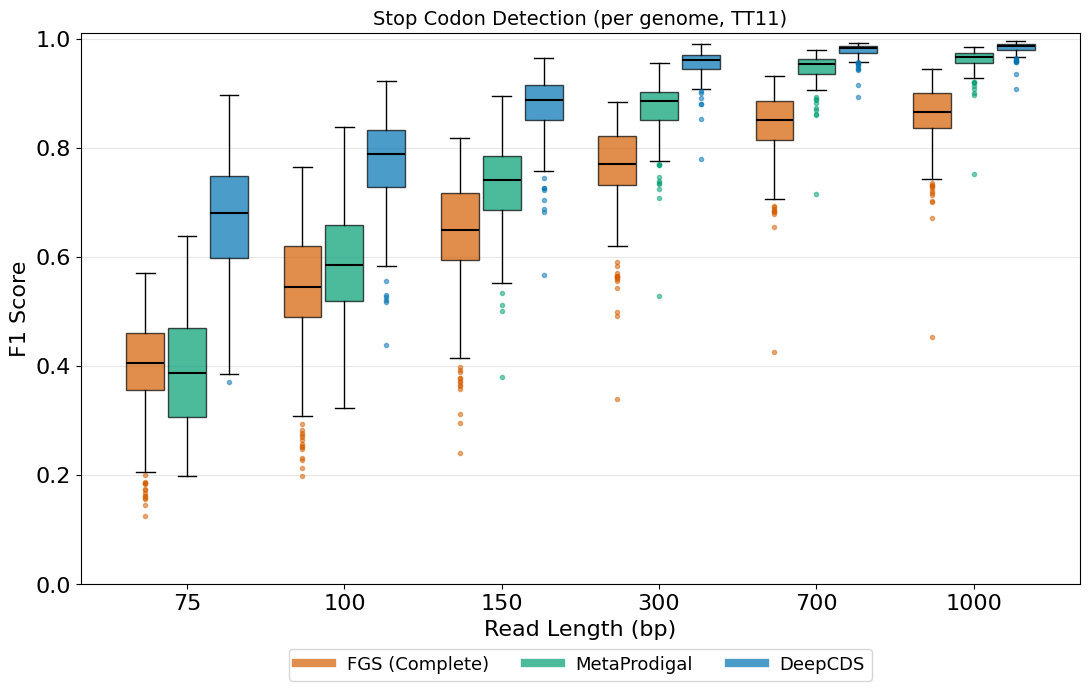

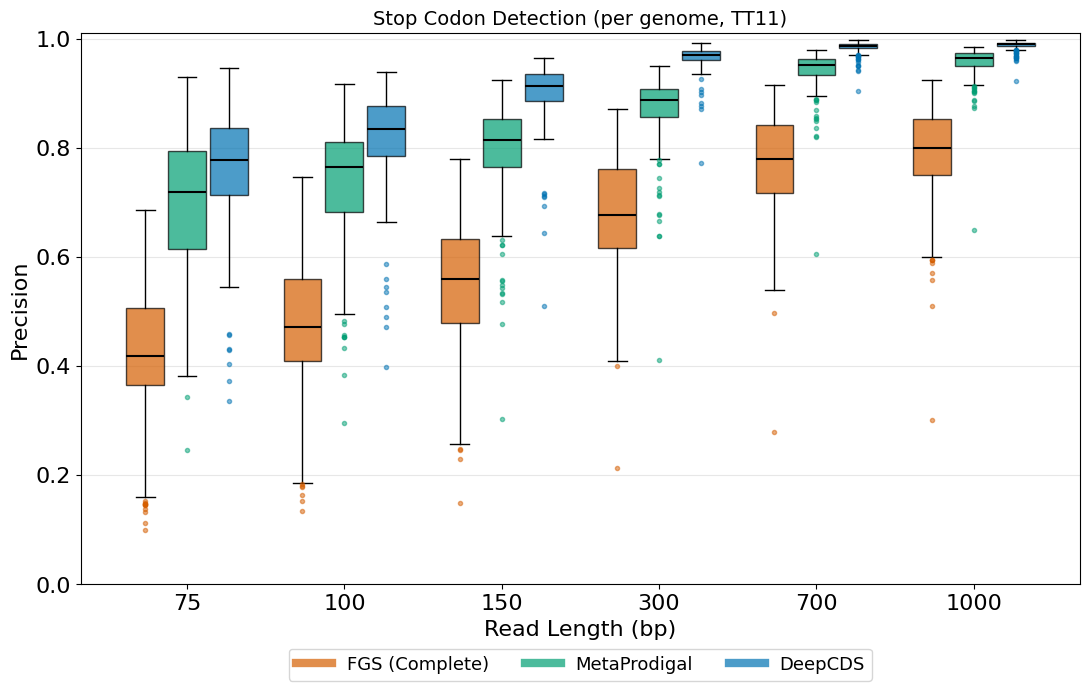

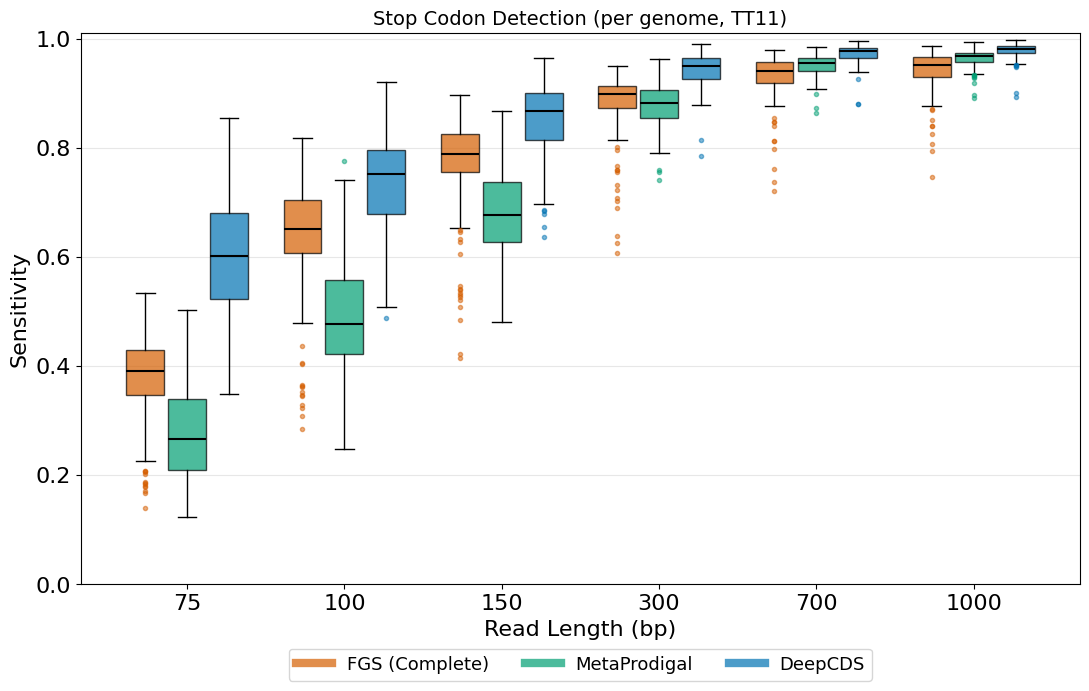

In [21]:
plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, 'stop_f1', 'F1 Score',
                          'Stop Codon Detection (per genome, TT11)')
plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, 'stop_precision', 'Precision',
                          'Stop Codon Detection (per genome, TT11)')
plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, 'stop_recall', 'Sensitivity',
                          'Stop Codon Detection (per genome, TT11)')

# LaTeX table

In [22]:
table_metrics = [
    ('start_f1', 'Start Codon F1'),
    ('start_precision', 'Start Codon Precision'),
    ('start_recall', 'Start Codon Sensitivity'),
    ('stop_f1', 'Stop Codon F1'),
    ('stop_precision', 'Stop Codon Precision'),
    ('stop_recall', 'Stop Codon Sensitivity'),
]

col_fmt = 'l' + 'c' * len(read_lengths)
header_cols = ' & '.join([f'{l}bp' for l in read_lengths])

lines = []
lines.append(r'\begin{table}[ht]')
lines.append(r'\centering')
lines.append(r'\caption{Aggregated start and stop codon prediction performance by read length.}')
lines.append(r'\label{tab:codon_read_length}')
lines.append(rf'\begin{{tabular}}{{{col_fmt}}}')
lines.append(r'\toprule')
lines.append(f'Model & {header_cols} \\\\')

for metric_key, metric_label in table_metrics:
    lines.append(r'\midrule')
    lines.append(rf'\multicolumn{{{1 + len(read_lengths)}}}{{l}}{{\textbf{{{metric_label}}}}} \\\\')
    lines.append(r'\midrule')
    
    best_per_length = []
    for i in range(len(read_lengths)):
        col_vals = [metrics[model][metric_key][i] for model in model_names]
        valid = [v for v in col_vals if not np.isnan(v)]
        best_per_length.append(max(valid) if valid else None)
    
    for model in model_names:
        display = model_display_names[model]
        vals = []
        for i in range(len(read_lengths)):
            v = metrics[model][metric_key][i]
            if np.isnan(v):
                vals.append('--')
            elif best_per_length[i] is not None and v == best_per_length[i]:
                vals.append(rf'\textbf{{{v:.3f}}}')
            else:
                vals.append(f'{v:.3f}')
        lines.append(f'{display} & ' + ' & '.join(vals) + r' \\')

lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\end{table}')

print('\n'.join(lines))

\begin{table}[ht]
\centering
\caption{Aggregated start and stop codon prediction performance by read length.}
\label{tab:codon_read_length}
\begin{tabular}{lcccccc}
\toprule
Model & 75bp & 100bp & 150bp & 300bp & 700bp & 1000bp \\
\midrule
\multicolumn{7}{l}{\textbf{Start Codon F1}} \\\\
\midrule
FGS (Complete) & 0.073 & 0.278 & 0.462 & 0.581 & 0.610 & 0.613 \\
MetaProdigal & 0.155 & 0.448 & 0.599 & 0.755 & 0.836 & 0.850 \\
DeepCDS & \textbf{0.455} & \textbf{0.686} & \textbf{0.811} & \textbf{0.886} & \textbf{0.902} & \textbf{0.906} \\
\midrule
\multicolumn{7}{l}{\textbf{Start Codon Precision}} \\\\
\midrule
FGS (Complete) & 0.138 & 0.390 & 0.541 & 0.571 & 0.573 & 0.573 \\
MetaProdigal & 0.392 & 0.501 & 0.617 & 0.767 & 0.850 & 0.861 \\
DeepCDS & \textbf{0.761} & \textbf{0.834} & \textbf{0.875} & \textbf{0.902} & \textbf{0.910} & \textbf{0.913} \\
\midrule
\multicolumn{7}{l}{\textbf{Start Codon Sensitivity}} \\\\
\midrule
FGS (Complete) & 0.050 & 0.216 & 0.403 & 0.591 & 0.652 & 0.660 \\


In [12]:

# Median F1 table derived from per-genome boxplot distributions
median_f1_metrics = [
    ('start_f1', 'Start Codon F1'),
    ('stop_f1',  'Stop Codon F1'),
]

col_fmt = 'l' + 'c' * len(read_lengths)
header_cols = ' & '.join([f'{l}bp' for l in read_lengths])

lines = []
lines.append(r'\begin{table}[ht]')
lines.append(r'\centering')
lines.append(r'\caption{Median start and stop codon F1 scores per genome by read length.}')
lines.append(r'\label{tab:codon_median_f1}')
lines.append(rf'\begin{{tabular}}{{{col_fmt}}}')
lines.append(r'\toprule')
lines.append(f'Model & {header_cols} \\\\')

for metric_key, metric_label in median_f1_metrics:
    lines.append(r'\midrule')
    lines.append(rf'\multicolumn{{{1 + len(read_lengths)}}}{{l}}{{\textbf{{{metric_label}}}}} \\\\')
    lines.append(r'\midrule')

    best_per_length = []
    for i, length in enumerate(read_lengths):
        col_vals = [np.median(per_genome_metrics_list[length][m][metric_key])
                    for m in model_names
                    if per_genome_metrics_list[length][m][metric_key]]
        best_per_length.append(max(col_vals) if col_vals else None)

    for model in model_names:
        display = model_display_names[model]
        vals = []
        for i, length in enumerate(read_lengths):
            data = per_genome_metrics_list[length][model][metric_key]
            if not data:
                vals.append('--')
            else:
                v = np.median(data)
                if best_per_length[i] is not None and np.isclose(v, best_per_length[i]):
                    vals.append(rf'\textbf{{{v:.3f}}}')
                else:
                    vals.append(f'{v:.3f}')
        lines.append(f'{display} & ' + ' & '.join(vals) + r' \\')

lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\end{table}')

print('\n'.join(lines))


\begin{table}[ht]
\centering
\caption{Median start and stop codon F1 scores per genome by read length.}
\label{tab:codon_median_f1}
\begin{tabular}{lcccccc}
\toprule
Model & 75bp & 100bp & 150bp & 300bp & 700bp & 1000bp \\
\midrule
\multicolumn{7}{l}{\textbf{Start Codon F1}} \\\\
\midrule
FGS (Complete) & 0.069 & 0.275 & 0.460 & 0.585 & 0.613 & 0.622 \\
MetaProdigal & 0.152 & 0.431 & 0.592 & 0.760 & 0.831 & 0.848 \\
DeepCDS & \textbf{0.438} & \textbf{0.687} & \textbf{0.819} & \textbf{0.889} & \textbf{0.906} & \textbf{0.909} \\
\midrule
\multicolumn{7}{l}{\textbf{Stop Codon F1}} \\\\
\midrule
FGS (Complete) & 0.406 & 0.545 & 0.649 & 0.771 & 0.851 & 0.865 \\
MetaProdigal & 0.388 & 0.585 & 0.742 & 0.886 & 0.954 & 0.966 \\
DeepCDS & \textbf{0.680} & \textbf{0.789} & \textbf{0.887} & \textbf{0.960} & \textbf{0.982} & \textbf{0.986} \\
\bottomrule
\end{tabular}
\end{table}
